# RUN GLOBAL ED WITH DIFFERENT INPUTS

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import SPSA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.utils import algorithm_globals

2026-07-13 17:24:04.274987: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-13 17:24:04.275473: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-13 17:24:04.342251: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-13 17:24:05.760255: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

# DATASETS

In [2]:
# datasets
SEED = 42

# changing it because it requires 4 inputs
X_class, y_class = make_classification(
    n_samples=200,
    n_features=4,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# synthetic dataset
X_s = X_class
y_s = y_class
X_s_tr, X_s_test, y_s_tr, y_s_test = train_test_split(
    X_s,
    y_s,
    test_size=0.4,
    random_state=SEED
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_s_tr = scaler.fit_transform(X_s_tr)
X_s_test = scaler.transform(X_s_test)


# this is already present in the full code - TO REMOVE
iris = load_iris(as_frame=True)

X = iris.data       
y = iris.target     

#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)


# binary dataset - setosa vs virginica
# already splitted and scaled above
X_b_tr = X_train_sv
X_b_test = X_test_sv
y_b_tr = y_train_sv
y_b_test = y_test_sv

X_b_tr = np.asarray(X_b_tr)
y_b_tr = np.asarray(y_b_tr)

X_b_test = np.asarray(X_b_test)
y_b_test = np.asarray(y_b_test)

# MODELS

In [3]:
'''
UPDATED VERSION OF THE CL MODEL WITH 60 PARAMETERS
'''

def build_model2(input_lenght=4, depth=2, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# defining models
CL_model = build_model2(input_lenght=4, depth=3, n_class=2) 

print(CL_model.count_params())

60


/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-13 17:24:51.229716: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


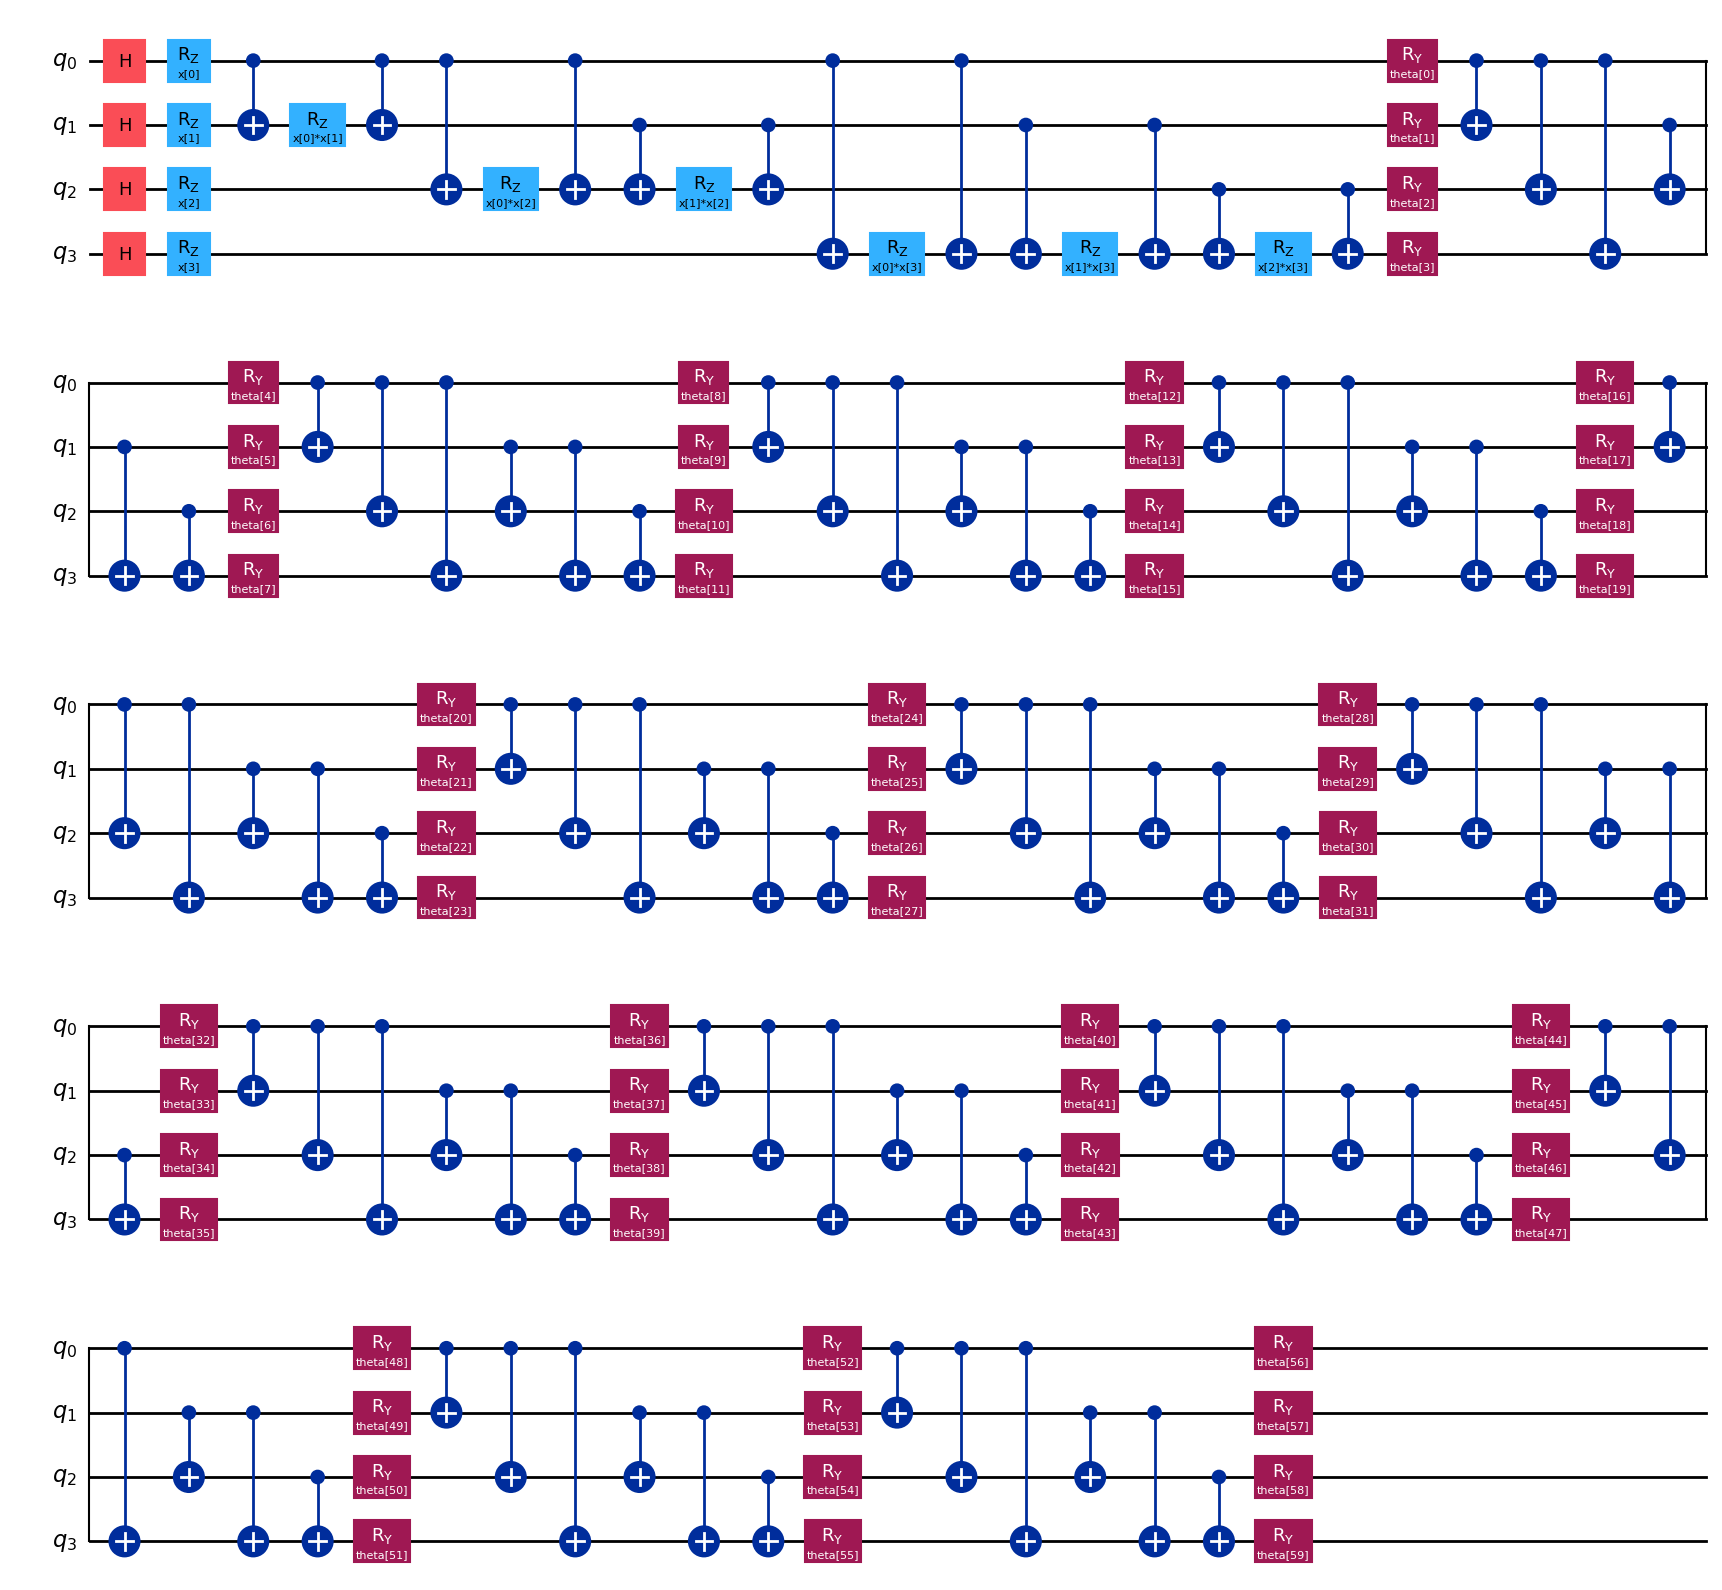

In [4]:
'''
QNN and EASY QNN with 60 parameters
'''

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc



# to have a QNN with 60 trainable parameters

def Ansatz_60_par(n_bits):
    theta = ParameterVector('theta', 15*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(14):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,N):
                qc.cx(i, j)
        qc.barrier()
        
    for i in range(n_bits):    
        qc.ry(theta[i+(l+1)*n_bits], i)
    qc.barrier()

    return qc


#-----------------------
# Parity Interpreter
# ----------------------
def parity(x):
    return "{:b}".format(x).count("1") % 2

def make_sampler_qnn(circ):
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

# defining models
N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz_60_par(N)


qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

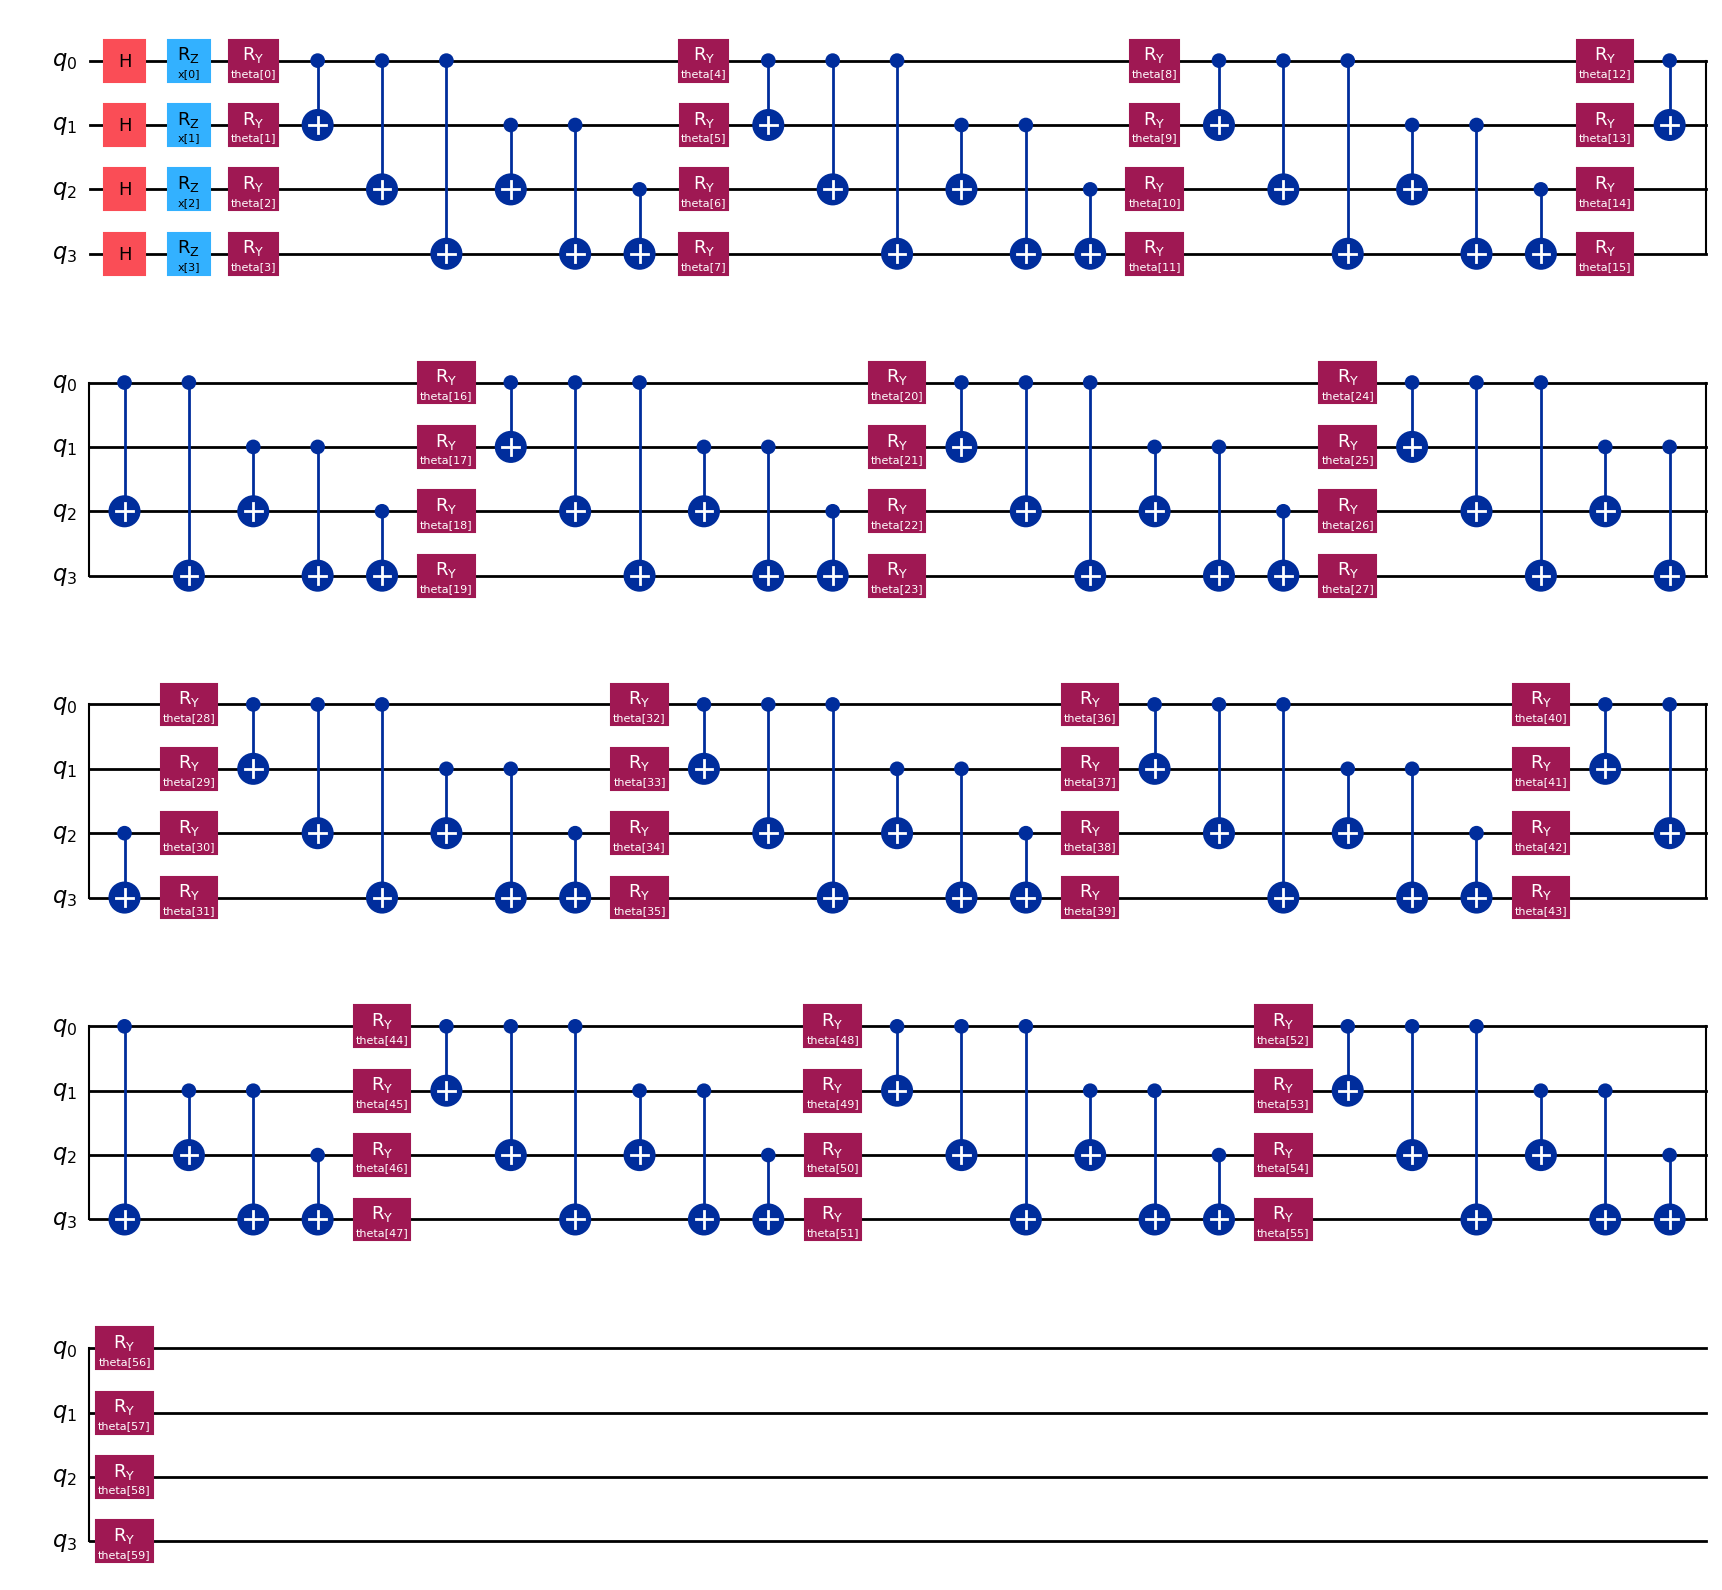

In [5]:
# defining models
# easy quantum model

qc_easy = easy_feature_map.copy().compose(ansatz.copy())
qc_easy.draw("mpl", style="iqp", plot_barriers=False)

# ED - SYNTHETIC DATASET

In [6]:
import pickle

algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

N = 4
qnn_s = make_sampler_qnn(qc)
qnn_s_easy = make_sampler_qnn(qc_easy)
d = qnn_s.num_weights   
m = qnn_s.num_inputs 
print(f'num_inputs : {m}')
print(f'num_weights: {d}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 60


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 1. GLOBAL EFFECTIVE DIMENSION
# Calcultated over the whole space parameter
# ══════════════════════════════════════════════════════════════════════
# in the standard EffectiveDimension():
# parameters are sampled uniformly in [-1,1]
# inputs are sampled from [-1,1] as well

# in the paper parameters are sampled uniformly in [-1,1] and inputs are sampled from N[0,1]
# I checked this in the GitHub repository
weights = np.random.uniform(-1, 1, size=(500,d))
#inputs = np.random.normal(0, 1, size=(100,m))

global_ed_qnn  = EffectiveDimension(qnn=qnn_s,      weight_samples=weights, input_samples=X_b_tr)
global_ed_easy = EffectiveDimension(qnn=qnn_s_easy, weight_samples=weights, input_samples=X_b_tr)


global_eff_qnn  = global_ed_qnn.get_effective_dimension(dataset_size=n)
print("DONE")
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

# save data
# Effective Dimension
with open("new_global_eff_qnn_bin.pkl", "wb") as f:
    pickle.dump(global_eff_qnn, f)
with open("new_global_eff_easy_bin.pkl", "wb") as f:
    pickle.dump(global_eff_easy, f)
'''